In [107]:
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.optimize import minimize

import matplotlib.pyplot as plt

import time

In [108]:
df_k = pd.read_csv('N2.csv')

In [109]:
def mape_loss(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # print(y_true, y_pred)

    errors = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(errors) * 100
    
    return mape

In [110]:
def k_model_poly(T, *coeffs):
    x = T**(-1/3)
    result = 0.0
    for k, coeff in enumerate(coeffs):
        result += coeff * (x ** k)
    return result

def fit_poly(df):
    params_arr = []
    pred_df = pd.DataFrame(index=df.index)
    for i in range(1, df.shape[1]):
        coeffs = []
        pred = []
        best_mape = np.inf
        print(i)
        
        for coeff_num in range(1, 7): 
            params, _ = curve_fit(k_model_poly, df.iloc[:, 0], np.log(df.iloc[:, i]), p0=np.ones(coeff_num))
            
            k_pred = np.exp(k_model_poly(df_k.iloc[:, 0], *params))
            mape_poly = mape_loss(df.iloc[:, i], k_pred)
            print(mape_poly)
            if mape_poly < best_mape:
                coeffs = params
                pred = k_pred
                print(coeff_num)
        print(coeffs)
        params_arr.append(coeffs)
        pred_df[i-1] = pred
    
    return params_arr, pred_df

In [111]:
start_time = time.time()

coeffs, pred_values = fit_poly(df_k)

end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения: {execution_time:.4f} секунд")

1
10278.366687147278
1
13.996225345175223
2
5.9351574463397725
3
2.1464151971937984
4
0.5725149818952261
5
0.0769751158150719
6
[-2.79907354e+01  3.65246824e+02 -1.08651892e+04  1.10980247e+05
 -5.70691023e+05  1.17414946e+06]
2
9131.053392005064
1
14.220956986447092
2
5.971791468489204
3
2.119716355278486
4
0.5482621403322341
5
0.06816295132110901
6
[-2.72838002e+01  3.59441090e+02 -1.06060586e+04  1.07604094e+05
 -5.50074602e+05  1.12592510e+06]
3
8105.6840491901785
1
14.440109208658233
2
6.000576534313559
3
2.0907384240521654
4
0.5233731790947944
5
0.05979545765490834
6
[-2.68542505e+01  3.52950398e+02 -1.03318665e+04  1.04075921e+05
 -5.28718271e+05  1.07630183e+06]
4
7189.942406217925
1
14.652230734026828
2
6.02090313821597
3
2.058071251373108
4
0.49798063141334753
5
0.05209861334069266
6
[-2.65324433e+01  3.45803172e+02 -1.00436437e+04  1.00411197e+05
 -5.06725710e+05  1.02553871e+06]
5
6372.698764484024
1
14.855727201481173
2
6.032156889330996
3
2.0213895788838743
4
0.4722291748

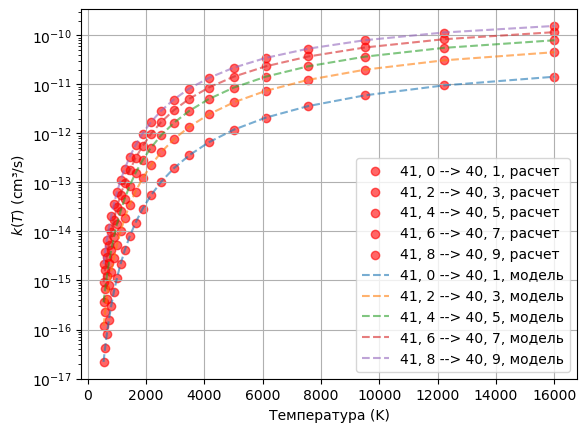

In [113]:
fig, ax = plt.subplots()
x_values = df_k.iloc[:, 0] 

for i in range(1, df_k.shape[1], 2):  
    y_values = df_k.iloc[:, i]
    ax.scatter(x_values, y_values, label=f'41, {i - 1} --> 40, {i}, расчет', color='red', alpha=0.6)
    
for i in range(0, pred_values.shape[1], 2):  
    y_values = pred_values.iloc[:, i]
    ax.plot(x_values, y_values, label=f'41, {i} --> 40, {i+1}, модель', linestyle='--', alpha=0.6)
    
ax.set_yscale('log')
plt.legend()
plt.grid(True)

plt.xlabel('Температура (K)')
plt.ylabel('$k(T)$ (cm³/s)')

fig.savefig('plot_VV_reg.png', dpi=600)
plt.show()
